In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression


from copula_mp import mp_density

In [2]:
# data-generating process
def generate_data(n):
    W = np.random.uniform(0, 1, n)
    Y_obs = np.random.normal(0, 1, n)
    X = np.zeros(n, dtype=int)
    
    probs = np.where(W > 0.5, 0.6, 0.4)
    treat_mask = np.random.uniform(0, 1, n) < probs
    
    X[treat_mask] = 1
    Y_obs[treat_mask] += (1 + W[treat_mask])
    
    return Y_obs, X, W

# True density function for Y(1) averaged over W
def true_y1_density(y_vals, n_w=200):
    w_grid = np.linspace(0, 1, n_w)
    mu = (1 + w_grid)
    dens = np.exp(-0.5 * ((y_vals[:, None] - mu[None, :]) ** 2)) / np.sqrt(2 * np.pi)
    return np.mean(dens, axis=1)

In [7]:
# load data
np.random.seed(42)
n = 200
y, x, w = generate_data(n)

# define parameters
y_grid = np.linspace(y.min() - 0.5, y.max() + 0.5, 100)
T_fwd, B_post = 1000, 100


# True density functions
true_y0 = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * y_grid**2)
true_y1 = true_y1_density(y_grid)

# fit martingale posteriors and compute density estimates
res = mp_density(y, x, w, [0, 1], y_grid, B_post, T_fwd)
res_c, res_t = res['x_0'], res['x_1']



Compiling...
Compilation time: 0.125s
Optimizing...
Optimization time: 1.135s
Fitting...
Fit time: 0.03s
Optimised rho:  0.18507415
Optimised rho_x:  [0.9324906  0.90806264]
Prequential log-likelihhod:  -1.4473780393600464
Predicting...
Prediction time: 4.513s
Predictive resampling...
Predictive resampling time: 87.184s


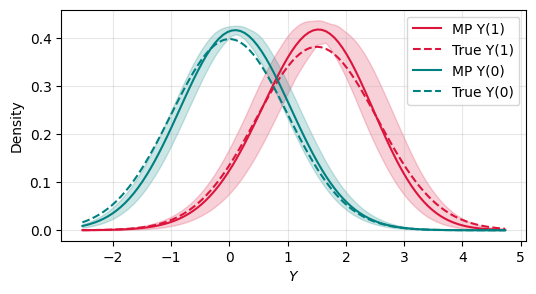

In [8]:

# plot results
plt.figure(figsize=(6, 3))

# Plot Treated Group
plt.plot(y_grid, res_t['mean'], color='crimson', label='MP Y(1)')
plt.fill_between(y_grid, res_t['low'], res_t['high'], color='crimson', alpha=0.2)
plt.plot(y_grid, true_y1, '--', color='crimson', label='True Y(1)')

# Plot Control Group
plt.plot(y_grid, res_c['mean'], color='teal', label='MP Y(0)')
plt.fill_between(y_grid, res_c['low'], res_c['high'], color='teal', alpha=0.2)
plt.plot(y_grid, true_y0, '--', color='teal', label='True Y(0)')

plt.xlabel('$Y$')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Figures/Density_Sim.pdf', dpi=300, bbox_inches='tight')
plt.show()